In [26]:
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image
from dinosaw.models.vit_wrapper import AlibiVitWrapper, MODEL_LIST
from dinosaw.helpers import get_features
from dinosaw.utils import do_2D_pca
DEVICE="cpu"

In [14]:
alibi_learned = AlibiVitWrapper(
    model_identifier=MODEL_LIST[1],
    slope_type="learned",
    add_flash_attn=False,
    device=DEVICE
)
alibi_learned.load_state_dict(torch.load("/home/ab_aimd_anja_20884/Pawlowsky_Moritz/England/DINOMO/dinosaw/experiments/20260208_1341_alibi_learned_slope_100_224_CB_bs128_1e-4_1_518_bs32/best_model.pth"))


/tmp/ipykernel_3744811/2023285612.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  alibi_learned.load_state_dict(torch.load("/home/ab_aimd_anja_20884/Pawlowsky_Moritz/Eng

<All keys matched successfully>

In [19]:
img_fname="wmg_si_c.png"

img_path = f"../images/{img_fname}"
img = Image.open(img_path).convert('RGB')

In [ ]:
feats_reduced = {channel_group: {} for channel_group in range(3)}

feats = get_features(alibi_learned, img, device=DEVICE)
for channel_group in range(3):
    feats_reduced[channel_group] = do_2D_pca(feats, (channel_group+1)*3, pre_norm=None, post_norm='minmax')[:, :, channel_group*3:channel_group*3+3]

KeyError: 'None'

In [ ]:
for channel_group in range(3):
    feats_reduced[channel_group] = do_2D_pca(feats, (channel_group+1)*3, pre_norm="std", post_norm='minmax')[:, :, channel_group*3:channel_group*3+3]

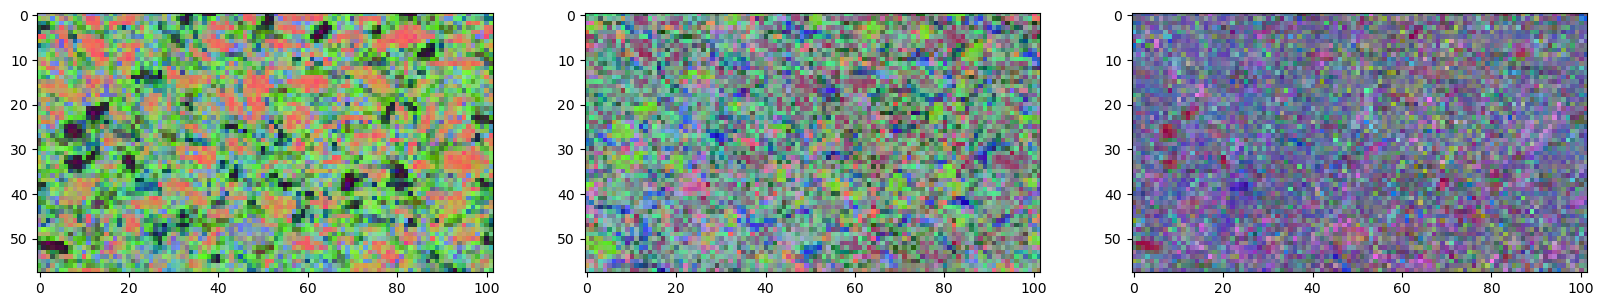

In [31]:
H,W = 20,20
NROWS, NCOLS = 1,3
fig = plt.figure(figsize=(W,H))
gs = GridSpec(NROWS, NCOLS, figure=fig)

for i, channel_group in enumerate(list(range(3))):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(feats_reduced[channel_group])